In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape

(95662, 16)

In [4]:
df.dtypes

TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

In [5]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [6]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


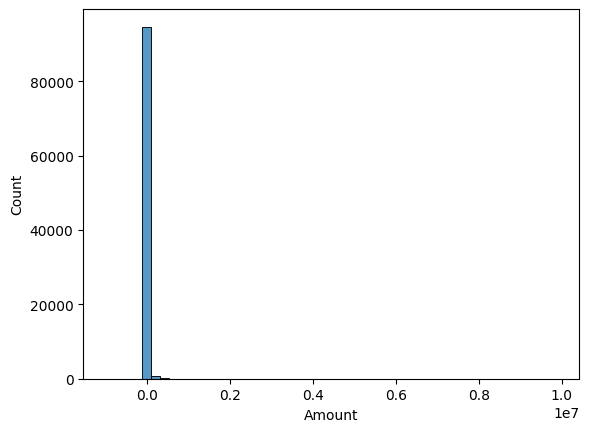

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Amount"], bins=50)
plt.show()

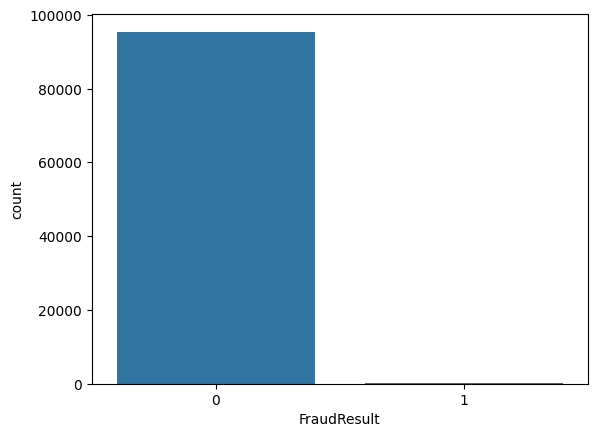

In [8]:
sns.countplot(x="FraudResult", data=df)
plt.show()

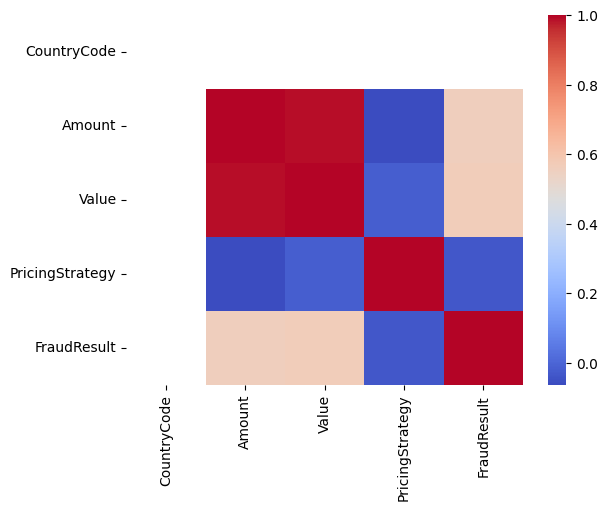

In [9]:
numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

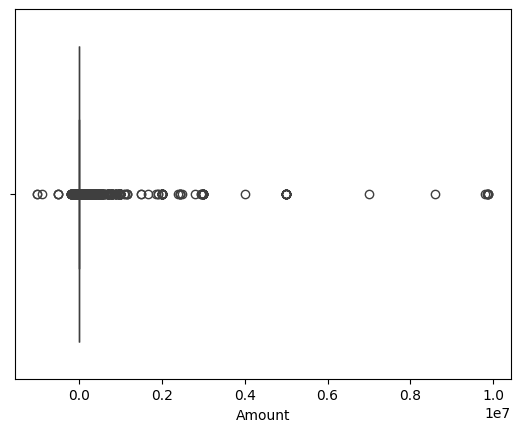

In [10]:
sns.boxplot(x=df["Amount"])
plt.show()

# Top Insights

1. The dataset contains transaction-level information describing customer purchases, channels, and payment behavior.

2. Transaction amounts are highly skewed and contain several outliers.

3. Fraudulent transactions represent a small proportion of the dataset, indicating potential class imbalance.

4. Certain transaction channels and product categories appear more frequently than others.

5. Missing values are limited and can be addressed through appropriate preprocessing techniques during feature engineering.


In [11]:
transaction_per_channel = (
    df["ChannelId"]
    .value_counts()
)

print(transaction_per_channel)

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64


In [12]:
product_category_counts = (
    df["ProductCategory"]
    .value_counts()
)

print(product_category_counts.head(10))

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64


In [13]:
fraud_rate = (
    df["FraudResult"]
    .value_counts(normalize=True) * 100
)

print(fraud_rate)

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64


# Key Findings

1. The majority of transactions were processed through a small number of channels, showing concentrated customer behavior.

2. Fraudulent transactions represented a very small percentage of the dataset, indicating class imbalance.

3. Transaction amounts were heavily right-skewed and contained significant outliers.

4. Product category usage was uneven, with a few categories dominating transaction volume.

5. Missing values were limited and can be handled during preprocessing.